In [59]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np


In [60]:
key1 = 'lambda_ic'
key2 = 'seed'
current_dir = 'gridsearch__2026-07-08--18-07-48'
#current_dir = os.getcwd()


In [61]:
def get_data(item_path, file_name):
    json_path = os.path.join(item_path, file_name)
    with open(json_path, 'r', encoding='utf-8') as f:
        return json.load(f)

data_full = {}

for item in sorted(os.listdir(current_dir)):
    item_path = os.path.join(current_dir, item)
    if not os.path.isdir(item_path):
        continue

    config = get_data(item_path, 'model_metadata.json')['args']
    report = get_data(item_path, 'report.json')

    data_full[item] = {
        key1: config[key1],
        key2: config[key2],
        'linf_pde': report['test_linf']['pde'],
        'linf_ic': report['test_linf']['ic'],
        'l2_pde': report['test_rel_l2']['pde'],
        'l2_ic': report['test_rel_l2']['ic'],
    }

print(f'Total reports loaded: {len(data_full)}')


Total reports loaded: 15


In [62]:
data_full

{'seed=13__lambda_ic=0p01': {'lambda_ic': 0.01,
  'seed': 13,
  'linf_pde': 0.23024974763393402,
  'linf_ic': 0.23086221516132355,
  'l2_pde': 0.12477789512985078,
  'l2_ic': 0.1448921461529311},
 'seed=13__lambda_ic=0p1': {'lambda_ic': 0.1,
  'seed': 13,
  'linf_pde': 0.08536835014820099,
  'linf_ic': 0.08641886711120605,
  'l2_pde': 0.04812260242470869,
  'l2_ic': 0.051717663413898704},
 'seed=13__lambda_ic=100p0': {'lambda_ic': 100.0,
  'seed': 13,
  'linf_pde': 0.08788324892520905,
  'linf_ic': 0.05820777267217636,
  'l2_pde': 0.07088264169492232,
  'l2_ic': 0.0443673736644701},
 'seed=13__lambda_ic=10p0': {'lambda_ic': 10.0,
  'seed': 13,
  'linf_pde': 0.07761047035455704,
  'linf_ic': 0.05866976082324982,
  'l2_pde': 0.05582454658938285,
  'l2_ic': 0.04442935521449766},
 'seed=13__lambda_ic=1p0': {'lambda_ic': 1.0,
  'seed': 13,
  'linf_pde': 0.06216007471084595,
  'linf_ic': 0.06127147376537323,
  'l2_pde': 0.04387698029411337,
  'l2_ic': 0.044693371258382304},
 'seed=42__lambda

In [63]:
metric_order = ['linf_pde', 'linf_ic', 'l2_pde', 'l2_ic']
metric_labels = {
    'linf_pde': r'$L^\infty$ (pde)',
    'linf_ic': r'$L^\infty$ (ic)',
    'l2_pde': r'rel $L^2$ (pde)',
    'l2_ic': r'rel $L^2$ (ic)',
}

def create_average_matrix():
    lambda_values = sorted({row[key1] for row in data_full.values()})
    data = np.full((len(metric_order), len(lambda_values)), np.nan)

    for col_idx, lambda_value in enumerate(lambda_values):
        matching_rows = [row for row in data_full.values() if row[key1] == lambda_value]
        for row_idx, metric_name in enumerate(metric_order):
            metric_values = [row[metric_name] for row in matching_rows]
            if metric_values:
                data[row_idx, col_idx] = sum(metric_values) / len(metric_values)

    return {
        'data': data,
        'row_labels': [metric_labels[idx] for idx in metric_order],
        'col_labels': lambda_values,
    }


In [64]:
def format_lambda_label(value):
    return f'{value:g}'

def plot_matrix(matrix, cmap='YlOrRd'):
    data = matrix['data']
    row_labels = matrix['row_labels']
    col_labels = matrix['col_labels']

    fig, ax = plt.subplots(figsize=(10, 4.5))
    im = ax.imshow(data, cmap=cmap, aspect='auto')

    ax.set_xticks(range(len(col_labels)))
    ax.set_yticks(range(len(row_labels)))
    ax.set_xticklabels([format_lambda_label(value) for value in col_labels])#, rotation=45, ha='right')
    ax.set_yticklabels(row_labels)

    ax.set_xlabel(r'$\lambda_{ic}$')
    #ax.set_ylabel('metric')
    ax.set_title('')

    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if not np.isnan(data[i, j]):
                ax.text(j, i, f'{data[i, j]:.4f}', ha='center', va='center', color='black')

    plt.colorbar(im, ax=ax) #, label='error')
    plt.tight_layout()
    plt.savefig('lambda_ic__GS.png')
    plt.show()


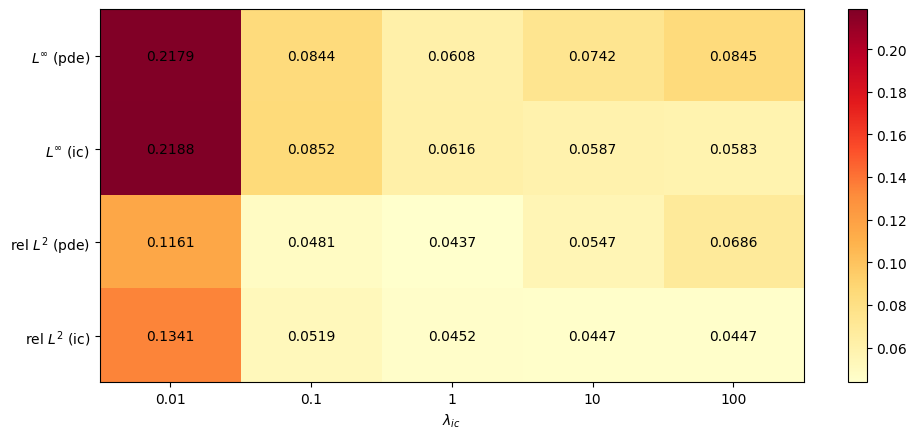

In [65]:
matrix = create_average_matrix()
plot_matrix(matrix, cmap='YlOrRd')